Mounted at /content/drive
📥 Cargando datos limpios desde Drive...
✅ Datos cargados: 891 registros
Columnas: ['Pclass', 'Sex_Code', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Code', 'AgeGroup_Code', 'FamilySize', 'IsAlone', 'Survived']
Train: 712 registros
Test: 179 registros

🤖 Entrenando modelo...

📊 RESULTADOS:
• Precisión: 81.56%
• AUC-ROC: 0.846

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


⭐ TOP 5 FACTORES DE RIESGO:
      Feature  Importance
1    Sex_Code    0.292999
5        Fare    0.235101
2         Age    0.178924
0      Pclass    0.093274
8  FamilySize    0.050865

📊 KPIs DE NEGOCIO:
• Tasa de supervivencia actual: 38.38%
• Tasa predicha: 33.52%
• Mejora potencial: -4.9%


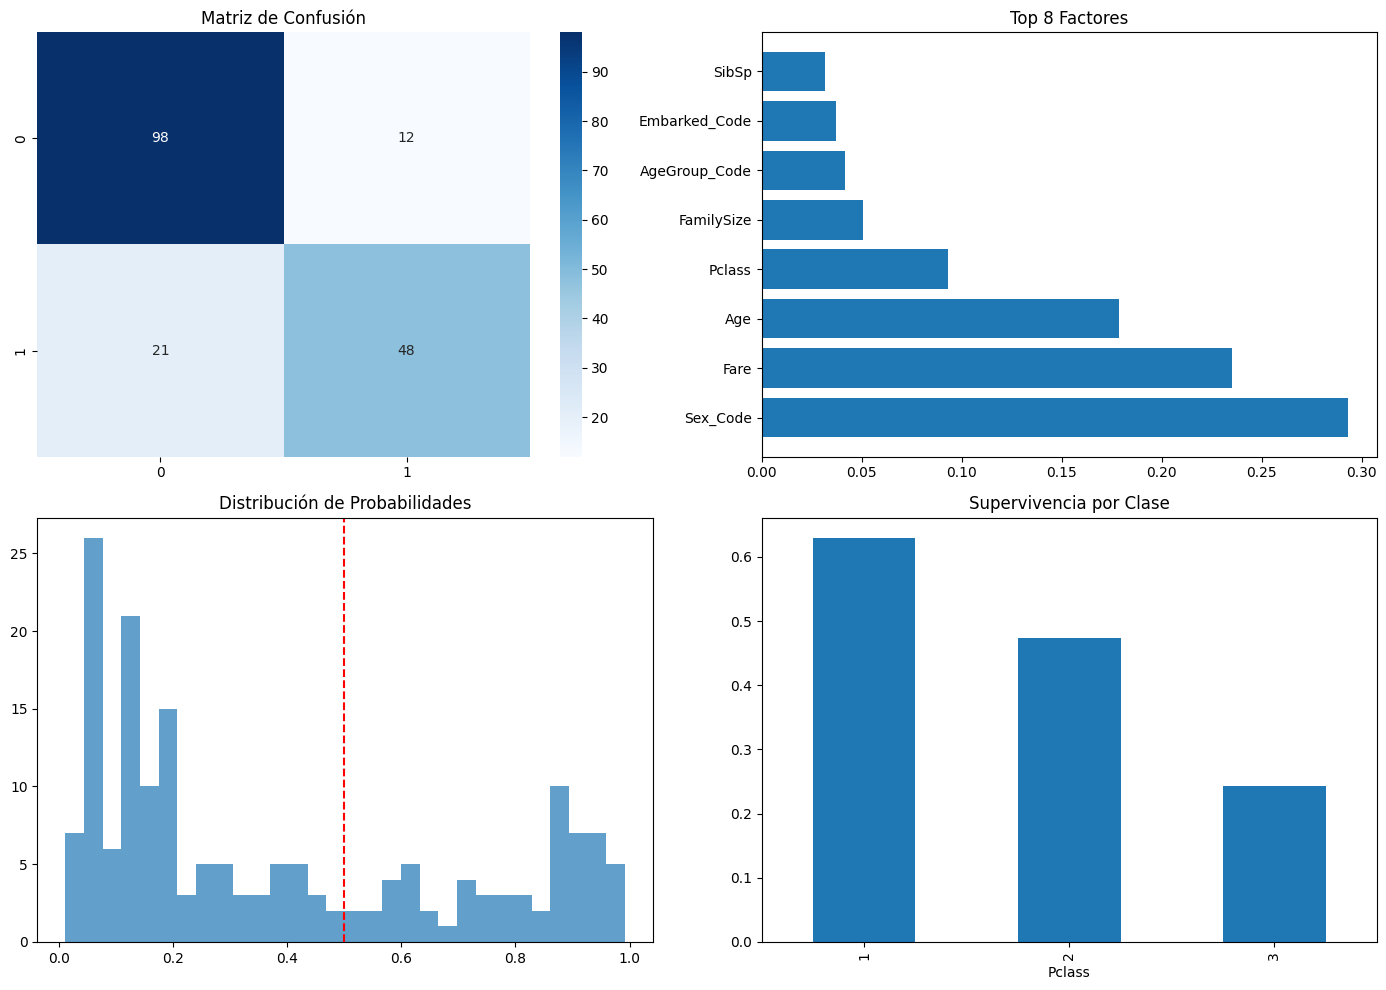


✅ Gráficos guardados en Drive
🎉 MODELO ML COMPLETADO


In [ ]:
# ============================================
# COLAB 2: MODELO ML - TITANIC (DESDE DRIVE)
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGAR DATOS LIMPIOS DESDE DRIVE
print("📥 Cargando datos limpios desde Drive...")
df = pd.read_csv('/content/drive/MyDrive/titanicBigdata/titanic_for_ml.csv')

print(f"✅ Datos cargados: {len(df)} registros")
print(f"Columnas: {df.columns.tolist()}")

# 2. PREPARAR PARA ML
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} registros")
print(f"Test: {len(X_test)} registros")

# 3. ENTRENAR MODELO
print("\n🤖 Entrenando modelo...")
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 4. EVALUAR
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n📊 RESULTADOS:")
print(f"• Precisión: {model.score(X_test, y_test):.2%}")
print(f"• AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# 5. FACTORES IMPORTANTES
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n⭐ TOP 5 FACTORES DE RIESGO:")
print(importance.head(5))

# 6. KPIs DE NEGOCIO
print("\n📊 KPIs DE NEGOCIO:")
print(f"• Tasa de supervivencia actual: {y.mean():.2%}")
print(f"• Tasa predicha: {y_pred.mean():.2%}")
print(f"• Mejora potencial: {(y_pred.mean() - y.mean()) * 100:.1f}%")
print(f"• Pasajeros en alto riesgo: {sum(y_proba < 0.3)} ({sum(y_proba < 0.3)/len(y_proba):.1%})")

# 7. GUARDAR MODELO EN DRIVE
joblib.dump(model, '/content/drive/MyDrive/titanicBigdata/titanic_model.pkl')
print("\n✅ Modelo guardado en Drive")

# 8. VISUALIZACIONES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Matriz de Confusión')

# Feature Importance
importance_plot = importance.head(8)
axes[0,1].barh(importance_plot['Feature'], importance_plot['Importance'])
axes[0,1].set_title('Top 8 Factores')

# Distribución de probabilidades
axes[1,0].hist(y_proba, bins=30, alpha=0.7)
axes[1,0].axvline(0.5, color='red', linestyle='--')
axes[1,0].set_title('Distribución de Probabilidades')

# Supervivencia por clase
survival_by_class = df.groupby('Pclass')['Survived'].mean()
survival_by_class.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Supervivencia por Clase')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/titanicBigdata/model_results.png')
plt.show()

print("\n✅ Gráficos guardados en Drive")
print("🎉 MODELO ML COMPLETADO")